합성곱 신경망(CNN)
CNN은 특히 이미지에 있는 특징을 찾아 압축하는 데 뛰어난 성능을 냅니다.
이번에는 CNN이 이미지에서 어떤 것을 학습했는지 알아보기 위해 합성곱층의 가중치와 특성맵을 그림으로 시각화하겠습니다.
이를 통해 CNN의 동작원리를 이해하는 시간이 될 것입니다.

지금까지는 keras의 Sequential 클래스만 사용했습니다. 하지만 keras는 함수형 API라는 좀 더 복잡한 모델을 찾을 수 있는 클래스를 제공합니다. 따라서 함수형 API도 살펴보겠습니다.

## 1. 가중치 시각화 (첫번째 방법)
CNN 층은 여러 개의 필터를 사용해 이미지에서 특징을 학습합니다. 각 필터는 커널이라 불리는 가중치와 절편을 가지고 있습니다.
일반적으로 절편은 시각적으로는 의미가 없습니다.반면에 가중치는 입력 이미지의 2차원 영역에 적용되어 어떤 특징을 가장 두드러지게 표현하는 역할을 합니다.

예를 들어, 둥근 모서리를 표현하는 가중치는 둥근 모서리가 있는 필터에서 크게 활성화 됩니다.
곡선이 있다면, 곡선부분의 가중치는 높고, 그 외 부분의 가중치는 낮게 활성화 되는 것입니다. 이렇게 해야 둥근 모서리가 있는 입력과 곱해져서 큰 출력을 만들 수 있기에 가중치는 이와 같이 작용합니다.

이제 'best-cnn-model.keras'를 로드하여 어떤 가중치를 학습했는지 확인하겠습니다.

In [1]:
!pip install numpy keras matplotlib plotly


import keras
import numpy
import matplotlib.pyplot as plt

model = keras.models.load_model('best-cnn-model.keras')


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 케라스 모델에 추가한 층은 layers 속성에 저장되어 있습니다. 정확히 무슨 말?
이 속성은 파이썬 리스트입니다. 
이제 model.layers를 출력해보겠습니다.

In [2]:
model.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

model.layers 리스트에 이전 절에서 추가했던 Conv2D, MaxPooling2D층이 변갈아 2번 연속 등장합니다.
그 다음 Flatten층과 Dense 층, Dropout 층이 차례대로 등장합니다.
마지막에 Dense 출력층이 있습니다.

이제 첫번째 CNN의 가중치를 조사해보겠습니다.
층의 가중치와 절편은 층의 weights 속성에 있습니다.
weights도 파이썬 리스트입니다.
이제 layers 속성의 첫번째 원소를 선택해 weights의 첫번째 원소(가중치)와 두번째 원소 절편을 출력하겠습니다.

In [3]:
conv = model.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


(3, 3, 1, 32) (32,)
위 정보의 해석은 다음과 같습니다.
커널 크기(3,3)
CNN 층에 전달되는 입력의 깊이 1
따라서 실제 커널의 크기 (3, 3, 1)
필터개수 32

따라서 weights의 첫번째 원소인 가중치의 크기는 (3, 3, 1, 32)이다.

weights의 두번째 원소인 절편의 크기는 필터의 개수가 32인 점을 빌려 필터당 1개의 절편이 있기에 32입니다.

결론
가중치의: (3, 3, 1, 32)
절편의 크기: 32

weights 속성은 텐서플로의 다차원 배열인 Tensor 클래스의 객체입니다.
## 다루기 쉽게 하기 위해서 numpy 배열로 변환합니다. 왜???
그 다음 가중치 배열의 평균과 표준편차를 numpy의 mean()과 std() 메서드로 계산합니다.

In [5]:
conv_weights = conv.weights[0].numpy()
print(conv_weights.mean(), conv_weights.std())

-0.040515475 0.27222183


이 가중치의 평균값은 0에 가깝고 표준편차는 0.27 정도입니다. 나중에 이 값을 훈련하기 전의 가중치와 비교하겠습니다.
이제 이 가중치를 이해하기 위해 히스토그램을 그려보도록 하겠습니다.

histogram을 그리기 위해서 알아야 할 점은 matplotlib의 hist() 함수에는 1차원 배열로 전달해야 합니다.
이를 위해 numpy의 reshape메서드로 conv_weights 배열을 1개의 열이 있는 배열로 변환했습니다.
plt.hist(conv_weights.reshape(-1, 1))에서 conv_weights.reshape(-1, 1)은 Conv2D 가중치를 전부 세로로 길게 펴는 코드입니다.

원래 shape:
(3, 3, 1, 32)

이걸 이렇게 바꿉니다.
(288, 1)

즉:
복잡한 4차원 필터 가중치 배열
↓
가중치 숫자 288개를 세로 한 줄로 정리

-1은 “개수는 자동으로 계산해라”라는 뜻입니다.
reshape(-1, 1)은 이렇게 읽으면 됩니다.

전체 숫자를 빠짐없이 사용해서,
열은 1개로 만들고,
행 개수는 알아서 맞춰라.


## 이걸 왜 보냐?

Conv2D 필터가 학습 전후로 어떻게 변했는지 확인하기 위해 봅니다.
학습 전에는 가중치가 보통 랜덤 초기화되어 있습니다.

학습 전:
작은 값들이 0 근처에 비교적 고르게 분포

학습 후에는 특정 패턴을 찾기 위해 가중치가 조정됩니다.

학습 후:
일부 가중치가 더 커지거나 작아짐
분포가 넓어질 수 있음
표준편차가 커질 수 있음

예를 들어 수업에서 이런 말을 했을 수 있습니다.

std 0.085 → 0.227

이 말은:

학습 후 가중치 분포가 더 넓어졌다
= 필터들이 더 강한 특징 탐지 패턴을 갖게 되었다

라고 해석할 수 있습니다.


## 평균과 표준편차와 연결하기

앞에서 이렇게 했죠.
print(conv_weights.mean(), conv_weights.std())

여기서:
값	의미
mean()	가중치들의 평균
std()	가중치들이 평균 주변에 얼마나 퍼져 있는지

히스토그램은 이걸 눈으로 보여주는 겁니다.

mean() = 중심 위치
std() = 퍼짐 정도
histogram = 전체 분포 모양

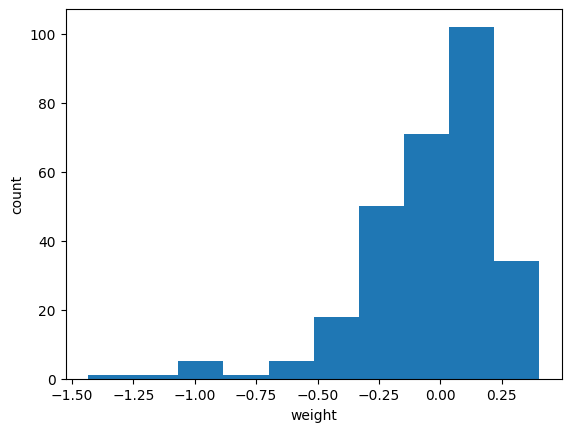

In [6]:
plt.hist(conv_weights.reshape(-1, 1))
plt.xlabel("weight")
plt.ylabel("count")
plt.show()

## 이번에는 32개의 커널을 16개씩 두 줄에 출력해보겠습니다. 왜??
맷플롯립의 subplot() 함수를 사용해서 32개의 그래프 영역을 만들고 순서대로 커널을 출력하겠습니다.

앞에서 conv_weights에 32개의 가중치를 저장했습니다.
## conv_weights = conv.weights[0].numpy()
이 배열의 마지막 차원을 순회하면서 0부터 i*16+j번째까지의 가중치 값을 차례대로 출력합니다. 
i는 행 인덱스이고 j는 열 인덱스로 각각 0~1, 0~15의 범위를 가집니다. 따라서 conv_weights[:,:,0,0]에서 conv_weights[:,:,0,31]까지 출력합니다.

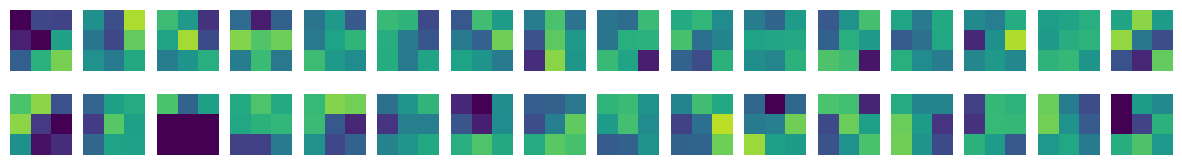

In [7]:
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:,:,0,i*16+j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

결과를 보면 이 가중치 값이 무작위로 나온 것이 아니라는 것을 확인할 수 있다고 합니다.
근거는 두번째 줄 왼쪽에서 8번째 가중치는 왼쪽 3픽셀이 다른 픽셀들보다 어두운 형태인데 값이 낮을 수록 어두운 형태를 보입니다.
그리고 이는 오른쪽에 놓인 직선을 만나면 해당 가중치가 크게 활성화 된다고 하는데 잘 모르겠습니다.
## 뭔 말?

imshow()함수는 배열에 있는 최댓값과 최솟값을 사용해 픽셀의 강도를 표현합니다.
즉, 0.1이나 0.4나 어떤 값이든지 그 배열의 최댓값이면 가장 밝은 노란색으로 표시합니다.
이 때문에 두 배열을 imshow() 함수로 표현하는 것은 적절치 않은 것입니다.
어떤 절댓값을 기준으로 해야하기에 vmin과 vmax를 이용해서 matplotlib의 색깔 표현 범위를 지정했습니다.

## 이제 훈련하지 않은 빈 합성곱 신경망을 만들어 보겠습니다. 
먼저,Sequential 클래스로 모델을 만들고 Conv2D 층을 하나 추가합니다.

In [ ]:
no_training_model.add(
    keras.layers.Input(shape=(28, 28, 1))
)
# Input 층을 추가합니다.
#
# 기본 형태:
# keras.layers.Input(shape=(height, width, channels))
#
# shape=(28, 28, 1)의 의미:
# 28 = 이미지 높이
# 28 = 이미지 너비
# 1  = 채널 수
#
# Fashion MNIST는 28x28 흑백 이미지이므로 채널 수가 1입니다.
#
# 주의:
# 여기에는 batch 크기인 60000 같은 전체 이미지 개수를 넣지 않습니다.
# 모델 입력층에는 이미지 한 장의 모양만 넣습니다.


In [ ]:
no_training_model.add(
    keras.layers.Conv2D(
        32,
        kernel_size=3,
        activation='relu',
        padding='same'
    )
)
# Conv2D는 합성곱 층입니다.
# 이미지 위에 작은 필터를 슬라이딩시키면서 특징을 뽑습니다.
#
# 32:
# 필터 개수입니다.
# 필터 1개는 feature map 1장을 만듭니다.
# 따라서 필터 32개는 feature map 32장을 만듭니다.
#
# kernel_size=3:
# 3x3 필터를 사용하겠다는 뜻입니다.
# kernel_size=3은 kernel_size=(3, 3)과 같은 의미입니다.
#
# activation='relu':
# 합성곱 계산 결과에 ReLU 활성화 함수를 적용합니다.
# ReLU는 음수는 0으로 만들고, 양수는 그대로 둡니다.
#
# padding='same':
# 입력 이미지와 출력 feature map의 가로세로 크기를 같게 유지합니다.
# 입력이 28x28이면 출력도 28x28입니다.
#
# 이 층의 출력 shape는 다음과 같습니다.
# (None, 28, 28, 32)
#
# None = batch size, 한 번에 몇 장 넣을지는 아직 고정하지 않음
# 28   = 출력 높이
# 28   = 출력 너비
# 32   = 필터 32개가 만든 feature map 32장


In [ ]:
no_training_conv = no_training_model.layers[0]
# no_training_model.layers는 모델 안에 들어 있는 층들의 리스트입니다.
#
# 현재 모델 구조:
# 0번 층: Conv2D
#
# Input 층은 경우에 따라 model.layers 목록에 별도 층으로 보이지 않을 수 있습니다.
# 그래서 no_training_model.layers[0]은 첫 번째 Conv2D 층입니다.
#
# no_training_conv에는 Conv2D 층 객체가 들어갑니다.

(3, 3, 1, 32)


In [ ]:
print(no_training_conv.weights[0].shape)
# no_training_conv.weights는 Conv2D 층이 가진 학습 파라미터 목록입니다.
#
# 보통 Conv2D의 weights는 두 개입니다.
#
# no_training_conv.weights[0] = kernel weight, 즉 필터 가중치
# no_training_conv.weights[1] = bias
#
# 여기서는 weights[0], 즉 필터 가중치의 shape를 출력합니다.
#
# 예상 출력:
# (3, 3, 1, 32)
#
# 의미:
# 3  = 필터 높이
# 3  = 필터 너비
# 1  = 입력 채널 수
# 32 = 필터 개수

In [10]:
no_training_weights = no_training_conv.weights[0].numpy()
print(no_training_weights.mean(), no_training_weights.std())

0.0007975486 0.08616812


이를 보면 평균은 0에 가깝지만 전의 결과인 -0.040515475 0.27222183 보다 표준편차의 값이 매우 작아진 걸 확인 할 수 있습니다.
## 표준편차의 의미는?


이제 위의 가중치 배열을 히스토그램으로 구현하겠습니다.

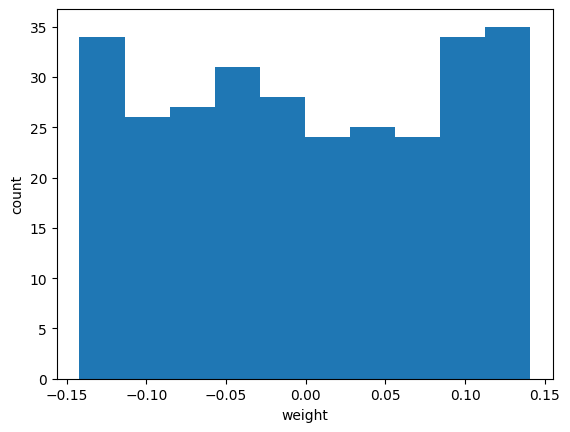

In [12]:
plt.hist(no_training_weights.reshape(-1, 1))
plt.xlabel("weight")
plt.ylabel("count")
plt.show()

이전과는 확실히 다른 결과입니다. 지금의 결과는 대부분의 가중치가 -0.15와 0.15 사이에 고르게 분포함을 알 수 있습니다.
-0.50부터 0.25까지 집중되어 고르지 못한 결과를 보여준 전과는 다른 결과입니다.

이제 해당 가중치값을 imshow() 함수를 통해 이전처럼 나타냅니다.

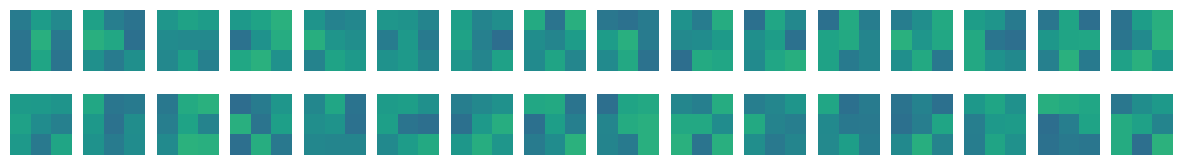

In [11]:
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(no_training_weights[:,:,0,i*16+j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

이전과는 다르게 전체적으로 밋밋한 결과들이 나옵니다. 이는 히스토그램에서도 확인할 수 있다시피 가중치가 고르게 분포되었기 때문입니다.

## 가중치 시각화 (두번째 방법)


두번째 방법은 합성곱 층에서 출력된 특성 맵을 그려보는 것입니다.
이를 통해 입력 이미지를 신경망이 어떻게 바라보는지 알 수 있습니다.
그 전에 함수형 API를 먼저 살펴보겠습니다.

## 함수형 API

지금까지는 신경망 모델을 만들 때 층을 차례대로 쌓는 케라스 Sequential을 사용했습니다. Sequentialdms 입력이 2개이거나 출력이 2개인 상황에서는 사용하기 힘듭니다. 
그래서 이러한 상황에서도 작동하는 함수형 API를 다루겠습니다.

함수형 API는 keras의 Model 클래스를 사용하여 모델을 만듭니다. 이해를 위해 Dense 층 2개로 만들었던 완전 연결 신경망을 함수API로 구현하겠습니다.

먼저 입력층과 2개의 Dense층을 만듭니다.

In [14]:
inputs = keras.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='relu')
dense2 = keras.layers.Dense(10, activation='softmax')

## 이 객체를 Sequential 클래스 객체 add() 메서드에 전달할 수 있습니다. 무슨 말이고? 
하지만 다음과 같이 함수처럼 호출할 수 있다고 합니다.

In [15]:
hidden = dense1(inputs)

사실 파이썬의 모든 객체는 호출가능합니다. 케라스의 층은 객체를 함수처럼 호출했을 때 동작할 수 있도록 미리 준비되어 있습니다.
위의 코드를 실행하면 입력값 inputs을 Dense층에 통과시킨 후 출력값 hidden을 만들어줍니다.

그 다음 두번째 층을 호출합니다.

In [16]:
outputs = dense2(hidden)

그 다음 inputs와 outputs를 Model 클래스로 연결해주면 됩니다.

In [17]:
func_model = keras.Model(inputs, outputs)

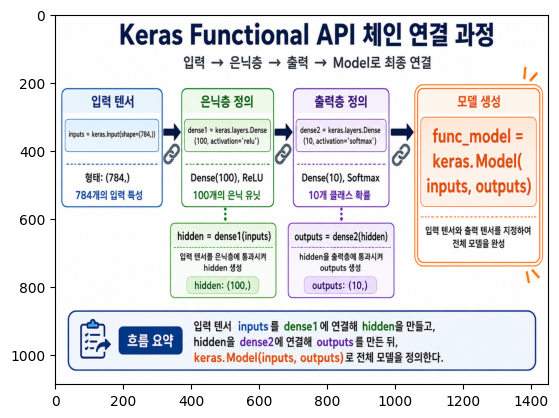

In [20]:
from PIL import Image
from ultralytics import YOLO
import matplotlib.pyplot as plt
img = Image.open("a.png")
plt.imshow(img)

그런데 특성 맵 시각화를 만드는 데 함수형 API가 필요할까요? 이는 다음과 같습니다.

model 객체 -> Conv2D (활성화출력)-> Maxpooling2D -> Conv2D -> Maxpooling2D -> Flatten -> Dense -> Dropout -> Dense

"위 과정은 model 객체의 층입니다. 보시면 첫번째 Conv2D 후에 활성화 출력이라는 표시를 알 수 있습니다. 우리가 필요한 것은 첫번째 Conv2D의 출력입니다. model 객체의 입력과 Conv2D의 출력을 알 수 있다면 이 둘을 연결하여 새로운 모델을 얻을 수 있지 않을까요?"

위의 글을 보고 이해가 가지 않아서 GPT에 물어봤습니다.
GPT: 
원래 모델은 입력 → 마지막 출력까지 가는 전체 공장입니다.
그런데 우리는 중간 결과, 즉 첫 번째 Conv2D가 만든 feature map만 보고 싶습니다.
그래서 “입력은 그대로 쓰고, 출력만 첫 번째 Conv2D 출력으로 바꾼 작은 모델”을 새로 만드는 겁니다.

원래 CNN 모델은 이런 흐름입니다

사용자님 모델은 대략 이렇게 생겼습니다.
입력 이미지
↓
Conv2D
↓
MaxPooling2D
↓
Conv2D
↓
MaxPooling2D
↓
Flatten
↓
Dense
↓
Dropout
↓
Dense
↓
최종 분류 결과

코드로 보면:

model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28, 1)))
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))

이 모델에 이미지를 넣으면 기본적으로 마지막 결과가 나옵니다.
model.predict(ankle_boot)

그러면 나오는 것은 10개 클래스 확률입니다.

예를 들면:
티셔츠 확률
바지 확률
스웨터 확률
...
앵클부츠 확률

즉, 원래 모델은 최종 정답 예측용 모델입니다.

2. 그런데 우리가 보고 싶은 것은 최종 정답이 아닙니다
특성 맵 시각화에서 보고 싶은 것은 이것입니다.

첫 번째 Conv2D가 이미지를 보고 만든 32장의 feature map. 즉, 이 부분입니다.

입력 이미지
↓
Conv2D ← 여기 출력이 궁금함
↓
MaxPooling2D
↓
Conv2D
↓
...
↓
최종 출력

첫 번째 Conv2D의 출력 shape는 보통 이렇습니다.
(1, 28, 28, 32)

뜻은:
이미지 1장
28×28 크기
특성 맵 32장

그런데 그냥 model.predict()를 하면 이 중간 결과가 아니라 맨 마지막 결과만 줍니다.

그래서 문제가 생깁니다.
내가 필요한 것: 첫 번째 Conv2D 출력
model.predict()가 주는 것: 마지막 Dense 출력

3. 그래서 새 모델을 만든다는 말입니다

원래 모델은 이렇게 생겼습니다.
입력 → Conv2D → MaxPool → Conv2D → MaxPool → Flatten → Dense → Output

우리는 이 전체 모델을 그대로 쓰지 않고, 앞부분만 잘라서 새 모델을 만듭니다.
입력 → Conv2D 출력

즉, 새 모델은 이렇게 생깁니다.

입력 이미지
↓
첫 번째 Conv2D
↓
첫 번째 Conv2D의 feature map 출력

이걸 코드로 만드는 것이 바로 이 줄입니다.

conv1_acti = keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)
4. 이 코드가 무슨 뜻이냐?
conv1_acti = keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

하나씩 보겠습니다.
keras.Model(...)
keras.Model(inputs=..., outputs=...)

이건 함수형 API 방식으로 모델을 만드는 코드입니다.

뜻은:
어디서 시작해서 어디까지 계산할지 직접 지정해서 모델을 만들겠다입니다.

Sequential 모델은 그냥 순서대로 쌓습니다.

처음부터 끝까지 자동 연결

반면 Functional API는 이렇게 말할 수 있습니다.

입력은 여기로 하고, 출력은 중간의 이 층으로 하겠다.

이게 핵심입니다.
inputs=model.inputs
inputs=model.inputs

뜻은 원래 model이 쓰던 입력을 그대로 쓰겠다입니다.

원래 모델의 입력은 (28, 28, 1)입니다.

즉, 새 모델도 똑같이 28×28 흑백 이미지를 받습니다.

outputs=model.layers[0].output
outputs=model.layers[0].output

뜻은:
출력은 원래 모델의 0번 층 출력으로 하겠다.
여기서 model.layers[0]은 첫 번째 Conv2D 층입니다.
주의할 점은, Input 층은 model.layers 목록에서 빠져 보이는 경우가 많습니다.

그래서 보통:
model.layers[0]은 첫 번째 Conv2D입니다.

그 층의 출력은:
model.layers[0].output


즉:
첫 번째 Conv2D가 만든 feature map을 새 모델의 출력으로 삼겠다라는 뜻입니다.

5. 그래서 새 모델 conv1_acti는 무엇인가?

conv1_acti는 전체 분류 모델이 아닙니다.

conv1_acti = keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

이 모델은 이렇게 생긴 모델입니다.

입력 이미지
↓
첫 번째 Conv2D
↓
첫 번째 Conv2D의 feature map 출력

즉, 원래 모델의 앞부분만 잘라낸 중간 출력 확인용 모델입니다.

6. 실제로 예측하면 뭐가 나오나?
feature_maps1 = conv1_acti.predict(ankle_boot)

여기서 ankle_boot의 shape가 (1, 28, 28, 1)이라고 합시다.
그러면 conv1_acti는 이 이미지를 첫 번째 Conv2D까지만 통과시킵니다.

결과는:
feature_maps1.shape
(1, 28, 28, 32)
이게 바로 첫 번째 Conv2D가 만든 특성 맵입니다.

7. 원래 모델과 새 모델 비교
구분	        입력	             출력	                            목적
model	    이미지 (28,28,1)	클래스 확률 (10,)	                  최종 분류
conv1_acti	이미지 (28,28,1)	Conv1 feature map (28,28,32)	중간 특성 맵 시각화

즉:
model은 정답 맞히는 모델
conv1_acti는 중간 결과 보는 모델입니다.

8. 비유로 설명하면
원래 모델을 공장이라고 해봅시다.

원재료 투입
↓
1번 기계
↓
2번 기계
↓
3번 기계
↓
최종 제품

원래는 최종 제품만 나옵니다.
model.predict() = 최종 제품 확인

그런데 우리는 1번 기계가 만든 중간 부품을 보고 싶습니다.

1번 기계가 뭘 만들었는지 보고 싶다

그러면 공장 전체를 다시 만들 필요는 없습니다.
입구는 그대로 두고, 출구를 1번 기계 뒤쪽에 새로 뚫으면 됩니다.

원재료 투입
↓
1번 기계
↓
여기서 꺼냄

이게 바로:

keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

9. “이 둘을 연결하여 새로운 모델을 얻는다”는 말의 뜻

문장에 나온:
model 객체의 입력과 Conv2D의 출력을 알 수 있다면 이 둘을 연결하여 새로운 모델을 얻을 수 있지 않을까요?

이 말은 이렇게 바꿔 이해하면 됩니다.

## 원래 모델의 입력 지점은 알고 있다. 첫 번째 Conv2D의 출력 지점도 알고 있다.
## 그러면 입력에서 첫 번째 Conv2D 출력까지 이어지는 새로운 모델을 만들 수 있다.

즉:
conv1_acti = keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

이 코드는 다음 의미입니다.

입구: 원래 모델의 입력
출구: 첫 번째 Conv2D의 출력

이 입구와 출구를 연결한 새 모델을 만들어라.
10. 전체 코드로 보면
# 원래 모델의 첫 번째 Conv2D 출력만 뽑는 새 모델 생성
conv1_acti = keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

# ankle_boot 이미지를 첫 번째 Conv2D까지만 통과시킴
feature_maps1 = conv1_acti.predict(ankle_boot)

# 출력 크기 확인
print(feature_maps1.shape)

결과:
(1, 28, 28, 32)

해석:
1장 이미지가 들어갔고,
첫 번째 Conv2D가 28×28짜리 feature map 32장을 만들었다.

11. 왜 Sequential만으로는 안 되냐?

Sequential 모델은 기본적으로 입력부터 마지막 출력까지 가는 모델입니다.
그래서 model.predict()를 하면 마지막 출력만 나옵니다.

model.predict(ankle_boot)
결과:(1, 10)

그런데 우리는 중간 결과가 필요합니다.
(1, 28, 28, 32)

그래서 Functional API 방식으로:
입력은 원래 입력, 출력은 중간층 출력을 지정하는 새 모델을 만드는 겁니다.

12. 정리하면

원래 모델:
입력 → Conv2D → MaxPool → Conv2D → MaxPool → Flatten → Dense → Dropout → Dense

특성 맵 시각화용 새 모델:
입력 → Conv2D

코드:
conv1_acti = keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

뜻:
원래 모델의 입력에서 시작해서
첫 번째 Conv2D의 출력까지만 계산하는 새 모델을 만든다.

핵심 한 문장
특성 맵 시각화를 위해 함수형 API를 쓰는 이유는, 원래 모델의 최종 출력이 아니라 중간층인 Conv2D의 출력을 새 모델의 출력으로 지정해야 하기 때문입니다. 즉, 입력은 원래 모델과 같게 두고, 출력만 첫 번째 Conv2D의 feature map으로 바꾼 모델을 새로 만드는 것입니다.

model 객체의 입력값 구하기!

In [21]:
print(model.inputs)

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer>]


이제 model.inputs의 첫번째 원소와 model.layers[0].output을 연결하는 새로운 conv_acti 모델을 만들 수 있습니다.

In [22]:
conv_acti = keras.Model(model.inputs[0], model.layers[0].output)

model 객체의 predict 메서드를 호출하면 최종 출력층의 확률을 반환합니다.
그러나 conv_acti의 predict 메서드를 호출하면 첫번째 Conv2D의 출력을 반환할 것입니다.

드디어 특성맵 시각화!!!

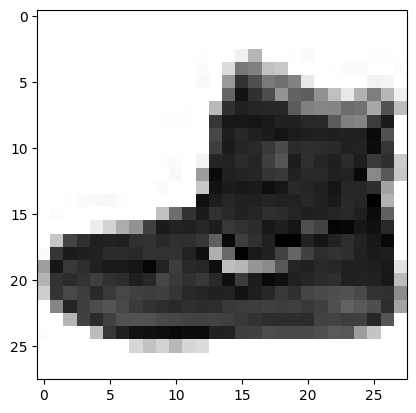

In [23]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

이 샘플을 conv_acti 모델에 주입하여 Conv2D층이 만드는 특성맵을 출력해보겠습니다.
predict메서드는 항상 입력의 첫번째 차원이 배치 차원일 것으로 기대한다고 합니다.
하나의 샘플을 유지하더라도 꼭 첫번째 차원을 유지해야 합니다.
이를 위해 슬라이싱 연산자를 사용해 첫번째 샘플을 선택합니다. 그 다음 (28, 28)크기를 (28,28,1)크기로 변경하고 255로 나눕니다. 전처리 과정!!

In [24]:
ankle_boot = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0
feature_maps = conv_acti.predict(ankle_boot)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


In [25]:
print(feature_maps.shape)

(1, 28, 28, 32)


In [ ]:
padding = "same"과 32개의 필터를 사용한 합성곱층의 출력이므로 (28,28,32)입니다.